# Net Spectral Resolution Optimizer

This notebook compares POPPY-measured spectral FWHM while automatically recalibrating focal lengths and focus distances for a fixed detector. The optimizer enforces full configured wavelength coverage and verifies the Nyquist–Shannon sampling requirement from the measured POPPY line profile.


In [31]:
# =============================================================================
# NET RESOLUTION CONFIGURATION — edit this cell, then run the cells below
# =============================================================================
from types import SimpleNamespace as NS
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import poppy
import poppy.fresnel as fresnel

CONFIG = NS(
    optics=NS(
        # Baseline values; comparison scenarios override slit/grating as needed.
        slit_width_um=20.0,
        pupil_diameter_mm=25.4,
        poppy_npix=512,
        lens_separation_mm=30.0,
    ),
    grating=NS(
        lines_per_mm=300.0,
        diffraction_order=1,
        incidence_angle_deg=0.0,
    ),
    detector=NS(
        # Detector dimensions remain fixed during automatic calibration.
        width_px=1440,
        height_px=1080,
        pixel_size_um=3.45,
        psf_fov_pixels=512,
    ),
    spectrum=NS(
        min_wavelength_nm=400.0,
        max_wavelength_nm=700.0,
        center_wavelength_nm=551.7,
    ),
    analysis=NS(
        resolution_curve_points=21,
        nyquist_target_pixels=2.2,
        detector_edge_margin_fraction=0.05,
        slit_widths_to_compare_um=(25.0, 50.0, 75.0, 100.0),
        gratings_to_compare_lines_per_mm=(300.0, 600.0, 900.0, 1200.0),
    ),
)


def validate_config(config=CONFIG):
    if config.detector.width_px <= 0 or config.detector.height_px <= 0:
        raise ValueError("Detector dimensions must be positive")
    if config.detector.pixel_size_um <= 0:
        raise ValueError("Detector pixel size must be positive")
    if config.optics.pupil_diameter_mm <= 0:
        raise ValueError("Pupil diameter must be positive")
    if config.spectrum.min_wavelength_nm >= config.spectrum.max_wavelength_nm:
        raise ValueError("Minimum wavelength must be below maximum wavelength")
    if config.analysis.nyquist_target_pixels < 2.0:
        raise ValueError("Nyquist target must be at least 2 pixels per FWHM")
    if not 0 <= config.analysis.detector_edge_margin_fraction < 0.5:
        raise ValueError("Detector edge margin must be between 0 and 0.5")


validate_config()
print(
    f"Fixed detector: {CONFIG.detector.width_px}×{CONFIG.detector.height_px}, "
    f"{CONFIG.detector.pixel_size_um:g} µm pixels; "
    f"Nyquist target: {CONFIG.analysis.nyquist_target_pixels:g} pixels/FWHM"
)


Fixed detector: 1440×1080, 3.45 µm pixels; Nyquist target: 2.2 pixels/FWHM


## Self-calibrating spectrograph class

The class maximizes the focusing focal length permitted by detector coverage, calibrates collimation for the Nyquist target, refocuses the distances, and then measures the final wavelength FWHM with POPPY.


In [32]:
from dataclasses import dataclass, replace
from scipy.ndimage import gaussian_filter1d
from scipy.signal import fftconvolve


@dataclass(frozen=True)
class SpectrographDesign:
    """One automatically focused and Nyquist-constrained spectrograph design."""

    slit_width_um: float
    grating_lines_per_mm: float
    collimator_focal_length_mm: float
    focusing_focal_length_mm: float
    slit_to_collimator_mm: float
    focusing_lens_to_detector_mm: float
    lens_separation_mm: float
    center_sampling_pixels: float
    detector_f_number: float
    wavelength_min_nm: float
    wavelength_max_nm: float


class SelfCalibratingSpectrograph:
    """Optimize geometry, run POPPY, and compare wavelength FWHM scenarios.

    Design rule
    -----------
    1. Keep the detector dimensions and pixel pitch fixed.
    2. Choose the longest focusing focal length that fits the entire configured
       wavelength range on the detector, including an edge margin.
    3. Choose the collimator focal length so the predicted center-wavelength
       line width meets ``nyquist_target_pixels`` (2.2 pixels by default).
    4. Set slit-to-collimator and focusing-lens-to-detector distances equal to
       their focal lengths, maintaining collimation and detector focus.

    POPPY calculates the lens diffraction profile. The projected slit and the
    finite illuminated-grating response are convolved before FWHM measurement.
    """

    def __init__(self, config=CONFIG):
        self.config = config
        self._psf_cache = {}

    @property
    def wavelength_grid(self):
        return np.linspace(
            self.config.spectrum.min_wavelength_nm,
            self.config.spectrum.max_wavelength_nm,
            self.config.analysis.resolution_curve_points,
        )

    def _grating_angle(self, wavelength_nm, lines_per_mm):
        spacing_nm = 1e6 / lines_per_mm
        alpha = np.deg2rad(self.config.grating.incidence_angle_deg)
        argument = (
            self.config.grating.diffraction_order * wavelength_nm / spacing_nm
            - np.sin(alpha)
        )
        if np.any(np.abs(argument) > 1):
            raise ValueError(
                f"{lines_per_mm:g} lines/mm has no real diffraction angle "
                f"for part of the configured wavelength range"
            )
        return np.arcsin(argument)

    def _coverage_limited_focus(self, lines_per_mm):
        """Longest focus that keeps both wavelength edges on the detector."""
        s = self.config.spectrum
        beta_min = self._grating_angle(s.min_wavelength_nm, lines_per_mm)
        beta_center = self._grating_angle(s.center_wavelength_nm, lines_per_mm)
        beta_max = self._grating_angle(s.max_wavelength_nm, lines_per_mm)

        largest_tangent_offset = max(
            abs(np.tan(beta_min) - np.tan(beta_center)),
            abs(np.tan(beta_max) - np.tan(beta_center)),
        )
        half_detector_mm = (
            self.config.detector.width_px
            * self.config.detector.pixel_size_um
            / 2000.0
        )
        usable_half_width_mm = half_detector_mm * (
            1.0 - self.config.analysis.detector_edge_margin_fraction
        )
        return usable_half_width_mm / largest_tangent_offset

    def _local_dispersion_nm_per_pixel(
        self, wavelength_nm, lines_per_mm, focusing_focal_length_mm
    ):
        """Exact local derivative for x=f*tan(beta), expressed per pixel."""
        spacing_nm = 1e6 / lines_per_mm
        beta = self._grating_angle(wavelength_nm, lines_per_mm)
        order = self.config.grating.diffraction_order
        return (
            spacing_nm
            * np.cos(beta) ** 3
            * (self.config.detector.pixel_size_um / 1000.0)
            / (order * focusing_focal_length_mm)
        )

    def calibrate(self, slit_width_um=None, grating_lines_per_mm=None):
        """Return a focused, detector-fitting, Nyquist-sampled design."""
        slit_width_um = float(
            self.config.optics.slit_width_um
            if slit_width_um is None else slit_width_um
        )
        grating_lines_per_mm = float(
            self.config.grating.lines_per_mm
            if grating_lines_per_mm is None else grating_lines_per_mm
        )

        focus_mm = self._coverage_limited_focus(grating_lines_per_mm)
        center_nm = self.config.spectrum.center_wavelength_nm
        beta_center = self._grating_angle(center_nm, grating_lines_per_mm)
        alpha = np.deg2rad(self.config.grating.incidence_angle_deg)
        dispersion = self._local_dispersion_nm_per_pixel(
            center_nm, grating_lines_per_mm, focus_mm
        )

        # Estimate non-slit sampling at the center: detector integration,
        # lens diffraction, and finite illuminated groove count.
        airy_fwhm_mm = (
            1.028
            * center_nm
            * 1e-6
            * focus_mm
            / self.config.optics.pupil_diameter_mm
        )
        airy_pixels = (
            airy_fwhm_mm
            / (self.config.detector.pixel_size_um / 1000.0)
        )
        illuminated_grooves = (
            grating_lines_per_mm * self.config.optics.pupil_diameter_mm
        )
        grating_fwhm_nm = (
            center_nm
            / (self.config.grating.diffraction_order * illuminated_grooves)
        )
        grating_pixels = grating_fwhm_nm / dispersion
        detector_pixels = 1.0
        non_slit_pixels = np.sqrt(
            airy_pixels**2 + grating_pixels**2 + detector_pixels**2
        )

        target_pixels = self.config.analysis.nyquist_target_pixels
        required_slit_pixels = np.sqrt(max(
            target_pixels**2 - non_slit_pixels**2,
            0.25**2,
        ))

        # Grating anamorphism for an entrance-angle spread, combined with
        # x=f*tan(beta), maps the physical slit onto the detector.
        anamorphic_detector_factor = (
            np.cos(alpha) / np.cos(beta_center) ** 3
        )
        collimator_mm = (
            slit_width_um
            * focus_mm
            * anamorphic_detector_factor
            / (required_slit_pixels * self.config.detector.pixel_size_um)
        )

        achieved_sampling = np.sqrt(
            non_slit_pixels**2 + required_slit_pixels**2
        )
        return SpectrographDesign(
            slit_width_um=slit_width_um,
            grating_lines_per_mm=grating_lines_per_mm,
            collimator_focal_length_mm=collimator_mm,
            focusing_focal_length_mm=focus_mm,
            slit_to_collimator_mm=collimator_mm,
            focusing_lens_to_detector_mm=focus_mm,
            lens_separation_mm=self.config.optics.lens_separation_mm,
            center_sampling_pixels=achieved_sampling,
            detector_f_number=(
                focus_mm / self.config.optics.pupil_diameter_mm
            ),
            wavelength_min_nm=self.config.spectrum.min_wavelength_nm,
            wavelength_max_nm=self.config.spectrum.max_wavelength_nm,
        )

    @staticmethod
    def _fractional_tophat(width_pixels):
        half_width = width_pixels / 2.0
        radius = int(np.ceil(half_width + 0.5))
        centers = np.arange(-radius, radius + 1, dtype=float)
        overlap = np.maximum(
            0.0,
            np.minimum(centers + 0.5, half_width)
            - np.maximum(centers - 0.5, -half_width),
        )
        return overlap / overlap.sum()

    @staticmethod
    def _fwhm(x, y):
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)
        if y.size < 3 or np.max(y) <= 0 or not np.isfinite(y).all():
            return np.nan
        peak = int(np.argmax(y))
        half = y[peak] / 2.0
        left = np.where(y[:peak] < half)[0]
        right = np.where(y[peak + 1:] < half)[0]
        if left.size == 0 or right.size == 0:
            return np.nan
        lb, la = left[-1], left[-1] + 1
        rb = peak + 1 + right[0]
        ra = rb - 1
        x_left = np.interp(half, [y[lb], y[la]], [x[lb], x[la]])
        x_right = np.interp(half, [y[rb], y[ra]], [x[rb], x[ra]])
        return abs(x_right - x_left)

    def _camera_profile(self, wavelength_nm, focusing_focal_length_mm):
        """Return a cached POPPY lens-diffraction line profile."""
        key = (round(float(wavelength_nm), 9), round(float(focusing_focal_length_mm), 9))
        if key in self._psf_cache:
            return self._psf_cache[key]

        osys = fresnel.FresnelOpticalSystem(
            name=f"Optimized camera at {wavelength_nm} nm",
            pupil_diameter=self.config.optics.pupil_diameter_mm * u.mm,
            npix=self.config.optics.poppy_npix,
        )
        osys.add_optic(poppy.CircularAperture(
            radius=self.config.optics.pupil_diameter_mm * u.mm / 2.0,
            name="Illuminated Camera Pupil",
        ))
        osys.add_optic(poppy.QuadraticLens(
            f_lens=focusing_focal_length_mm * u.mm,
            name="Focusing Lens",
        ))
        osys.add_detector(
            pixelscale=(
                self.config.detector.pixel_size_um * u.micron / u.pixel
            ),
            fov_pixels=self.config.detector.psf_fov_pixels,
            distance=focusing_focal_length_mm * u.mm,
        )
        psf = osys.calc_psf(wavelength=wavelength_nm * u.nm)[0].data
        profile = np.sum(psf, axis=0)
        self._psf_cache[key] = profile
        return profile

    def detector_coverage_mask(self, design, wavelengths_nm=None):
        """Return True for wavelengths that physically land on the detector."""
        wavelengths_nm = (
            self.wavelength_grid
            if wavelengths_nm is None else np.asarray(wavelengths_nm, dtype=float)
        )
        beta = self._grating_angle(
            wavelengths_nm, design.grating_lines_per_mm
        )
        beta_center = self._grating_angle(
            self.config.spectrum.center_wavelength_nm,
            design.grating_lines_per_mm,
        )
        detector_x_mm = design.focusing_focal_length_mm * (
            np.tan(beta) - np.tan(beta_center)
        )
        usable_half_width_mm = (
            self.config.detector.width_px
            * self.config.detector.pixel_size_um
            / 2000.0
            * (1.0 - self.config.analysis.detector_edge_margin_fraction)
        )
        return np.abs(detector_x_mm) <= usable_half_width_mm

    def simulate_fwhm(self, design, wavelengths_nm=None, show_progress=True):
        """Run POPPY and return measured spectral FWHM across wavelength."""
        wavelengths_nm = (
            self.wavelength_grid
            if wavelengths_nm is None else np.asarray(wavelengths_nm, dtype=float)
        )
        results = []
        alpha = np.deg2rad(self.config.grating.incidence_angle_deg)
        order = self.config.grating.diffraction_order
        spacing_nm = 1e6 / design.grating_lines_per_mm

        for index, wavelength_nm in enumerate(wavelengths_nm, start=1):
            if show_progress:
                print(
                    f"  POPPY {index}/{len(wavelengths_nm)}: "
                    f"λ={wavelength_nm:.1f} nm"
                )
            optical_profile = self._camera_profile(
                wavelength_nm, design.focusing_focal_length_mm
            )
            pixels = np.arange(optical_profile.size, dtype=float)
            peak = float(np.argmax(optical_profile))
            beta0 = self._grating_angle(
                wavelength_nm, design.grating_lines_per_mm
            )

            anamorphic_factor = np.cos(alpha) / np.cos(beta0) ** 3
            projected_slit_pixels = (
                design.slit_width_um
                * design.focusing_focal_length_mm
                * anamorphic_factor
                / (
                    design.collimator_focal_length_mm
                    * self.config.detector.pixel_size_um
                )
            )
            slit_profile = fftconvolve(
                optical_profile,
                self._fractional_tophat(projected_slit_pixels),
                mode="same",
            )

            x_relative = (
                (pixels - peak)
                * self.config.detector.pixel_size_um
                / 1000.0
            )
            beta_axis = np.arctan(
                np.tan(beta0)
                + x_relative / design.focusing_focal_length_mm
            )
            wavelength_axis_nm = (
                spacing_nm * (np.sin(alpha) + np.sin(beta_axis)) / order
            )
            dispersion = abs(np.gradient(wavelength_axis_nm)[int(peak)])

            grooves = (
                design.grating_lines_per_mm
                * self.config.optics.pupil_diameter_mm
            )
            grating_fwhm_nm = wavelength_nm / (order * grooves)
            grating_sigma_pixels = (
                grating_fwhm_nm
                / dispersion
                / (2 * np.sqrt(2 * np.log(2)))
            )
            final_profile = gaussian_filter1d(
                slit_profile, grating_sigma_pixels, mode="constant"
            )
            results.append(self._fwhm(wavelength_axis_nm, final_profile))

        return np.asarray(results)

    def enforce_nyquist(self, design, max_iterations=8):
        """Tune collimation until POPPY's measured center FWHM meets Nyquist."""
        center_nm = self.config.spectrum.center_wavelength_nm
        target = self.config.analysis.nyquist_target_pixels
        previous_sampling = None

        for _ in range(max_iterations):
            center_fwhm_nm = self.simulate_fwhm(
                design,
                wavelengths_nm=[center_nm],
                show_progress=False,
            )[0]
            dispersion = self._local_dispersion_nm_per_pixel(
                center_nm,
                design.grating_lines_per_mm,
                design.focusing_focal_length_mm,
            )
            actual_sampling = center_fwhm_nm / dispersion
            if not np.isfinite(actual_sampling):
                raise RuntimeError("POPPY could not measure the center-wavelength FWHM")
            if abs(actual_sampling - target) <= 0.02:
                return replace(
                    design,
                    center_sampling_pixels=actual_sampling,
                )
            if (
                previous_sampling is not None
                and abs(actual_sampling - previous_sampling) < 1e-3
            ):
                break

            # Slit image width is inversely proportional to collimator focal
            # length. Limit each correction to keep the iteration stable.
            correction = np.clip(actual_sampling / target, 0.6, 1.6)
            new_collimator = (
                design.collimator_focal_length_mm * correction
            )
            design = replace(
                design,
                collimator_focal_length_mm=new_collimator,
                slit_to_collimator_mm=new_collimator,
                center_sampling_pixels=actual_sampling,
            )
            previous_sampling = actual_sampling

        # Preserve the final measured value and fail loudly if undersampled.
        center_fwhm_nm = self.simulate_fwhm(
            design,
            wavelengths_nm=[center_nm],
            show_progress=False,
        )[0]
        dispersion = self._local_dispersion_nm_per_pixel(
            center_nm,
            design.grating_lines_per_mm,
            design.focusing_focal_length_mm,
        )
        actual_sampling = center_fwhm_nm / dispersion
        design = replace(design, center_sampling_pixels=actual_sampling)
        if actual_sampling < 2.0:
            raise RuntimeError(
                f"Nyquist constraint failed: measured FWHM is "
                f"{actual_sampling:.2f} pixels"
            )
        return design

    def compare(self, parameter, values):
        """Auto-calibrate and simulate every requested scenario."""
        if parameter not in {"slit_width_um", "grating_lines_per_mm"}:
            raise ValueError(
                "parameter must be 'slit_width_um' or 'grating_lines_per_mm'"
            )
        results = {}
        for value in values:
            kwargs = {parameter: value}
            design = self.calibrate(**kwargs)
            design = self.enforce_nyquist(design)
            print(
                f"\nCalibrated {parameter}={value:g}: "
                f"f_coll={design.collimator_focal_length_mm:.2f} mm, "
                f"f_focus={design.focusing_focal_length_mm:.2f} mm, "
                f"sampling={design.center_sampling_pixels:.2f} px, "
                f"f/{design.detector_f_number:.2f}"
            )
            if design.detector_f_number < 0.5:
                print("  WARNING: this requires an extremely fast focusing optic")
            results[value] = {
                "design": design,
                "fwhm_nm": self.simulate_fwhm(design),
            }
        return results

    def plot_fwhm(self, results, scenario_label):
        """Plot POPPY-measured FWHM and print each calibrated design."""
        wavelengths_nm = self.wavelength_grid
        fig, ax = plt.subplots(figsize=(10, 6))
        colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(results)))
        for color, (value, result) in zip(colors, results.items()):
            ax.plot(
                wavelengths_nm,
                result["fwhm_nm"],
                "o-",
                color=color,
                linewidth=2,
                markersize=4,
                label=f"{value:g} {scenario_label}",
            )
        ax.set_title(f"Spectral FWHM Comparison: {scenario_label}")
        ax.set_xlabel("Wavelength (nm)")
        ax.set_ylabel(r"FWHM $\Delta\lambda$ (nm)")
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.legend()
        plt.tight_layout()
        plt.show()

        print("\nCalibrated designs:")
        for value, result in results.items():
            d = result["design"]
            print(
                f"  {value:g} {scenario_label}: "
                f"f_coll={d.collimator_focal_length_mm:.2f} mm, "
                f"f_focus={d.focusing_focal_length_mm:.2f} mm, "
                f"slit→coll={d.slit_to_collimator_mm:.2f} mm, "
                f"focus→detector={d.focusing_lens_to_detector_mm:.2f} mm, "
                f"sampling={d.center_sampling_pixels:.2f} px"
            )


## Scenario 1 — different slit widths

The FWHM plot holds the calibrated optical geometry fixed so the effect of 25, 50, 75, and 100 µm slits remains visible. A separate report then gives the independently self-calibrated focal length required for each slit to return to the Nyquist limit.


  POPPY 1/21: λ=400.0 nm
  POPPY 2/21: λ=415.0 nm
  POPPY 3/21: λ=430.0 nm
  POPPY 4/21: λ=445.0 nm
  POPPY 5/21: λ=460.0 nm
  POPPY 6/21: λ=475.0 nm
  POPPY 7/21: λ=490.0 nm
  POPPY 8/21: λ=505.0 nm
  POPPY 9/21: λ=520.0 nm
  POPPY 10/21: λ=535.0 nm
  POPPY 11/21: λ=550.0 nm
  POPPY 12/21: λ=565.0 nm
  POPPY 13/21: λ=580.0 nm
  POPPY 14/21: λ=595.0 nm
  POPPY 15/21: λ=610.0 nm
  POPPY 16/21: λ=625.0 nm
  POPPY 17/21: λ=640.0 nm
  POPPY 18/21: λ=655.0 nm
  POPPY 19/21: λ=670.0 nm
  POPPY 20/21: λ=685.0 nm
  POPPY 21/21: λ=700.0 nm
  POPPY 1/21: λ=400.0 nm
  POPPY 2/21: λ=415.0 nm
  POPPY 3/21: λ=430.0 nm
  POPPY 4/21: λ=445.0 nm
  POPPY 5/21: λ=460.0 nm
  POPPY 6/21: λ=475.0 nm
  POPPY 7/21: λ=490.0 nm
  POPPY 8/21: λ=505.0 nm
  POPPY 9/21: λ=520.0 nm
  POPPY 10/21: λ=535.0 nm
  POPPY 11/21: λ=550.0 nm
  POPPY 12/21: λ=565.0 nm
  POPPY 13/21: λ=580.0 nm
  POPPY 14/21: λ=595.0 nm
  POPPY 15/21: λ=610.0 nm
  POPPY 16/21: λ=625.0 nm
  POPPY 17/21: λ=640.0 nm
  POPPY 18/21: λ=655.0 nm
  PO

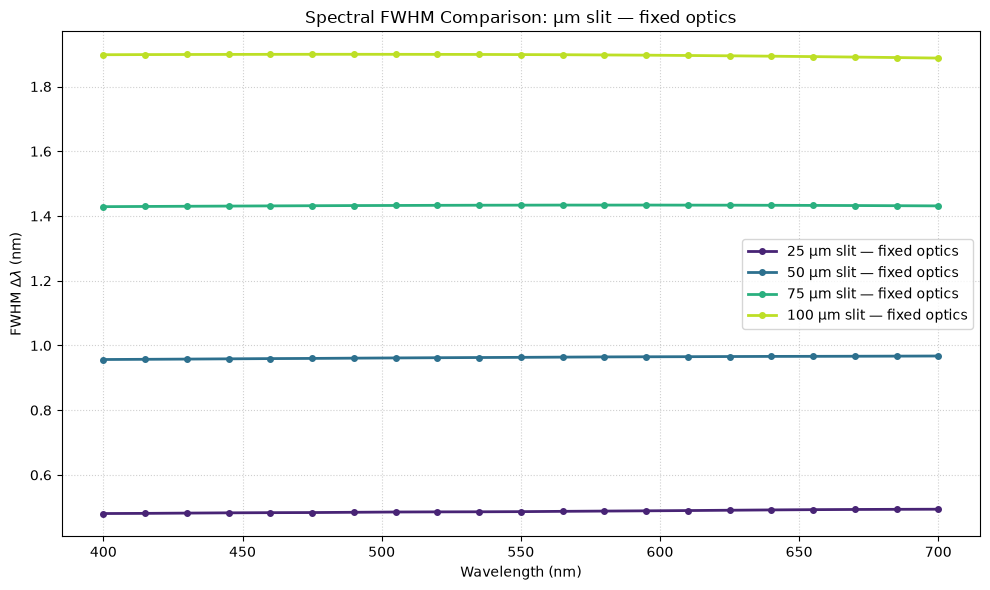


Calibrated designs:
  25 µm slit — fixed optics: f_coll=179.06 mm, f_focus=50.25 mm, slit→coll=179.06 mm, focus→detector=50.25 mm, sampling=2.22 px
  50 µm slit — fixed optics: f_coll=179.06 mm, f_focus=50.25 mm, slit→coll=179.06 mm, focus→detector=50.25 mm, sampling=2.22 px
  75 µm slit — fixed optics: f_coll=179.06 mm, f_focus=50.25 mm, slit→coll=179.06 mm, focus→detector=50.25 mm, sampling=2.22 px
  100 µm slit — fixed optics: f_coll=179.06 mm, f_focus=50.25 mm, slit→coll=179.06 mm, focus→detector=50.25 mm, sampling=2.22 px

Common geometry used for the visible slit comparison:
  f_coll = 179.06 mm
  f_focus = 50.25 mm
  slit → collimator = 179.06 mm
  focusing lens → detector = 50.25 mm

Self-calibrated geometry required for each slit:
     25 µm: f_coll=179.06 mm, f_focus=50.25 mm, sampling=2.22 px
     50 µm: f_coll=358.11 mm, f_focus=50.25 mm, sampling=2.22 px
     75 µm: f_coll=537.17 mm, f_focus=50.25 mm, sampling=2.22 px
    100 µm: f_coll=716.22 mm, f_focus=50.25 mm, sampli

In [33]:
# =============================================================================
# SCENARIO 1A — FWHM COMPARISON WITH THE SAME OPTICS FOR EVERY SLIT
# =============================================================================
spectrograph = SelfCalibratingSpectrograph(CONFIG)

# Calibrate one common optical geometry using the smallest requested slit.
# All other slit widths are then inserted without changing either focal length.
reference_slit_um = min(CONFIG.analysis.slit_widths_to_compare_um)
common_design = spectrograph.enforce_nyquist(
    spectrograph.calibrate(slit_width_um=reference_slit_um)
)

fixed_optics_slit_scenarios = {}
for slit_width_um in CONFIG.analysis.slit_widths_to_compare_um:
    design = replace(common_design, slit_width_um=float(slit_width_um))
    fixed_optics_slit_scenarios[slit_width_um] = {
        "design": design,
        "fwhm_nm": spectrograph.simulate_fwhm(design),
    }

spectrograph.plot_fwhm(
    fixed_optics_slit_scenarios,
    "µm slit — fixed optics",
)

print("\nCommon geometry used for the visible slit comparison:")
print(f"  f_coll = {common_design.collimator_focal_length_mm:.2f} mm")
print(f"  f_focus = {common_design.focusing_focal_length_mm:.2f} mm")
print(f"  slit → collimator = {common_design.slit_to_collimator_mm:.2f} mm")
print(f"  focusing lens → detector = {common_design.focusing_lens_to_detector_mm:.2f} mm")


# =============================================================================
# SCENARIO 1B — SELF-CALIBRATED DESIGN REQUIREMENTS
# =============================================================================
# Optimizing every slit independently drives all designs toward the same
# Nyquist-limited FWHM. Instead of plotting overlapping curves, report the
# different focal lengths and distances required by each physical slit.
print("\nSelf-calibrated geometry required for each slit:")
for slit_width_um in CONFIG.analysis.slit_widths_to_compare_um:
    optimized = spectrograph.enforce_nyquist(
        spectrograph.calibrate(slit_width_um=slit_width_um)
    )
    print(
        f"  {slit_width_um:>5.0f} µm: "
        f"f_coll={optimized.collimator_focal_length_mm:.2f} mm, "
        f"f_focus={optimized.focusing_focal_length_mm:.2f} mm, "
        f"sampling={optimized.center_sampling_pixels:.2f} px"
    )


## Scenario 2 — different diffraction gratings

Each grating is independently recalibrated. The optimizer selects focal lengths and focus distances that fit the complete configured wavelength range on the fixed detector, then iteratively verifies the 2.2-pixel Nyquist target using the measured POPPY profile.



Calibrated grating_lines_per_mm=300: f_coll=143.24 mm, f_focus=50.25 mm, sampling=2.22 px, f/1.98
  POPPY 1/21: λ=400.0 nm
  POPPY 2/21: λ=415.0 nm
  POPPY 3/21: λ=430.0 nm
  POPPY 4/21: λ=445.0 nm
  POPPY 5/21: λ=460.0 nm
  POPPY 6/21: λ=475.0 nm
  POPPY 7/21: λ=490.0 nm
  POPPY 8/21: λ=505.0 nm
  POPPY 9/21: λ=520.0 nm
  POPPY 10/21: λ=535.0 nm
  POPPY 11/21: λ=550.0 nm
  POPPY 12/21: λ=565.0 nm
  POPPY 13/21: λ=580.0 nm
  POPPY 14/21: λ=595.0 nm
  POPPY 15/21: λ=610.0 nm
  POPPY 16/21: λ=625.0 nm
  POPPY 17/21: λ=640.0 nm
  POPPY 18/21: λ=655.0 nm
  POPPY 19/21: λ=670.0 nm
  POPPY 20/21: λ=685.0 nm
  POPPY 21/21: λ=700.0 nm

Calibrated grating_lines_per_mm=600: f_coll=68.57 mm, f_focus=21.07 mm, sampling=2.21 px, f/0.83
  POPPY 1/21: λ=400.0 nm
  POPPY 2/21: λ=415.0 nm
  POPPY 3/21: λ=430.0 nm
  POPPY 4/21: λ=445.0 nm
  POPPY 5/21: λ=460.0 nm
  POPPY 6/21: λ=475.0 nm
  POPPY 7/21: λ=490.0 nm
  POPPY 8/21: λ=505.0 nm
  POPPY 9/21: λ=520.0 nm
  POPPY 10/21: λ=535.0 nm
  POPPY 11/21: 

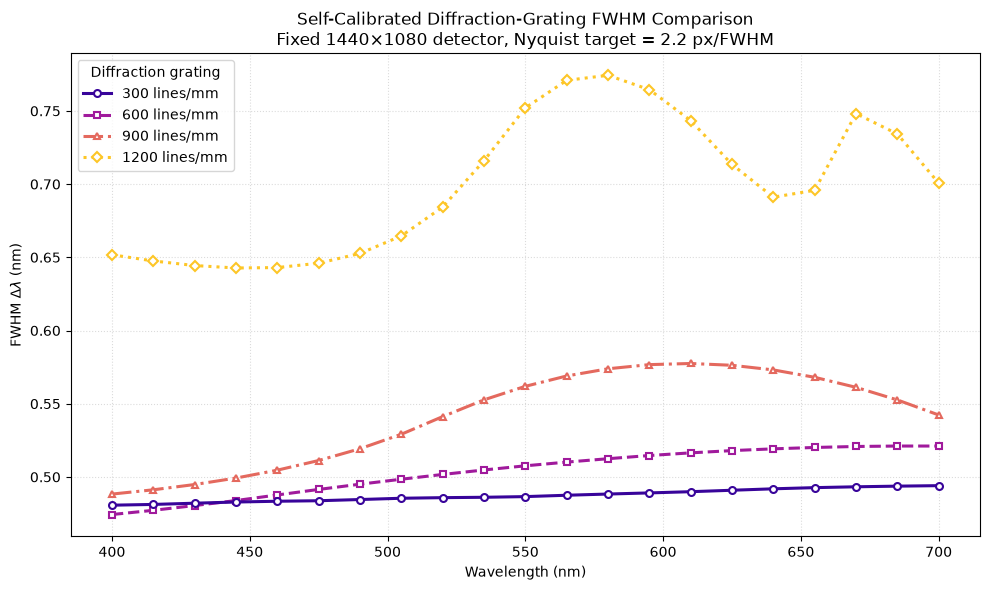


Calibrated designs:
    300 lines/mm: f_coll=143.24 mm, f_focus=50.25 mm, slit→coll=143.24 mm, focus→detector=50.25 mm, f/1.98, sampling=2.22 px
    600 lines/mm: f_coll=68.57 mm, f_focus=21.07 mm, slit→coll=68.57 mm, focus→detector=21.07 mm, f/0.83, sampling=2.21 px
    900 lines/mm: f_coll=41.24 mm, f_focus=9.87 mm, slit→coll=41.24 mm, focus→detector=9.87 mm, f/0.39, sampling=2.21 px
   1200 lines/mm: f_coll=23.06 mm, f_focus=3.55 mm, slit→coll=23.06 mm, focus→detector=3.55 mm, f/0.14, sampling=2.21 px

Interpretation: all designs cover the same configured wavelength range on the fixed detector and are adjusted to the same Nyquist target. Close FWHM curves are therefore expected; the calibrated focal lengths show the mechanical trade-off required for each grating.


In [34]:
# =============================================================================
# SCENARIO 2 — INDEPENDENTLY SELF-CALIBRATED DIFFRACTION GRATINGS
# =============================================================================
# Each groove density gets its own detector-fitting focusing focal length,
# Nyquist-calibrated collimator focal length, and corresponding focus distances.
spectrograph = SelfCalibratingSpectrograph(CONFIG)
grating_scenarios = spectrograph.compare(
    "grating_lines_per_mm",
    CONFIG.analysis.gratings_to_compare_lines_per_mm,
)

# Use a dedicated presentation for this comparison because independently
# optimized curves can be close to one another near the Nyquist boundary.
wavelengths_nm = spectrograph.wavelength_grid
grating_values = list(grating_scenarios)
colors = plt.cm.plasma(np.linspace(0.08, 0.88, len(grating_values)))
markers = ("o", "s", "^", "D")
line_styles = ("-", "--", "-.", ":")

fig, ax_curve = plt.subplots(figsize=(10, 6))

for index, (lines_per_mm, result) in enumerate(grating_scenarios.items()):
    ax_curve.plot(
        wavelengths_nm,
        result["fwhm_nm"],
        color=colors[index],
        linestyle=line_styles[index % len(line_styles)],
        marker=markers[index % len(markers)],
        linewidth=2.2,
        markersize=5,
        markerfacecolor="white",
        markeredgewidth=1.5,
        label=f"{lines_per_mm:g} lines/mm",
        zorder=10 - index,
    )

ax_curve.set_title("FWHM Across Wavelength")
ax_curve.set_xlabel("Wavelength (nm)")
ax_curve.set_ylabel(r"FWHM $\Delta\lambda$ (nm)")
ax_curve.grid(True, linestyle=":", alpha=0.45)
ax_curve.legend(title="Diffraction grating", frameon=True)

ax_curve.set_title(
    "Self-Calibrated Diffraction-Grating FWHM Comparison\n"
    f"Fixed {CONFIG.detector.width_px}×{CONFIG.detector.height_px} detector, "
    f"Nyquist target = {CONFIG.analysis.nyquist_target_pixels:g} px/FWHM"
)
plt.tight_layout()
plt.show()

print("\nCalibrated designs:")
for lines_per_mm, result in grating_scenarios.items():
    design = result["design"]
    print(
        f"  {lines_per_mm:>5.0f} lines/mm: "
        f"f_coll={design.collimator_focal_length_mm:.2f} mm, "
        f"f_focus={design.focusing_focal_length_mm:.2f} mm, "
        f"slit→coll={design.slit_to_collimator_mm:.2f} mm, "
        f"focus→detector={design.focusing_lens_to_detector_mm:.2f} mm, "
        f"f/{design.detector_f_number:.2f}, "
        f"sampling={design.center_sampling_pixels:.2f} px"
    )

print(
    "\nInterpretation: all designs cover the same configured wavelength range "
    "on the fixed detector and are adjusted to the same Nyquist target. "
    "Close FWHM curves are therefore expected; the calibrated focal lengths "
    "show the mechanical trade-off required for each grating."
)


## Raw-detector Nyquist sampling demonstration

The same monochromatic line is recorded with a deliberately undersampled design and with the measured 2.2-pixel Nyquist calibration. The calculation creates full raw detector arrays; magnified pixel-grid crops are shown because the sampling difference is not visible at full 1440×1080 scale.


In [ ]:
# =============================================================================
# RAW DETECTOR DEMONSTRATION: UNDERSAMPLED vs NYQUIST-SAMPLED
# =============================================================================
from scipy.ndimage import convolve1d

demo_wavelength_nm = CONFIG.spectrum.center_wavelength_nm
demo_grating_lines_per_mm = CONFIG.grating.lines_per_mm
demo_photons = 1_000_000.0
displayed_slit_length_pixels = 80.0  # Spatial length; FWHM is measured horizontally.

spectrograph = SelfCalibratingSpectrograph(CONFIG)
nyquist_design = spectrograph.enforce_nyquist(
    spectrograph.calibrate(
        slit_width_um=CONFIG.optics.slit_width_um,
        grating_lines_per_mm=demo_grating_lines_per_mm,
    )
)

# A much longer collimator makes the projected slit too narrow for the detector.
# Distances track the changed collimator so this remains an internally focused
# comparison, but it deliberately violates the sampling requirement.
undersampled_collimator_mm = (
    nyquist_design.collimator_focal_length_mm * 10.0
)
undersampled_design = replace(
    nyquist_design,
    collimator_focal_length_mm=undersampled_collimator_mm,
    slit_to_collimator_mm=undersampled_collimator_mm,
)


def raw_monochromatic_frame(design, wavelength_nm):
    """Return a full monochrome raw frame and its horizontal sampled profile."""
    cfg = spectrograph.config
    focus_mm = design.focusing_focal_length_mm

    osys = fresnel.FresnelOpticalSystem(
        name=f"Nyquist demonstration at {wavelength_nm:g} nm",
        pupil_diameter=cfg.optics.pupil_diameter_mm * u.mm,
        npix=cfg.optics.poppy_npix,
    )
    osys.add_optic(poppy.CircularAperture(
        radius=cfg.optics.pupil_diameter_mm * u.mm / 2.0,
        name="Illuminated Camera Pupil",
    ))
    osys.add_optic(poppy.QuadraticLens(
        f_lens=focus_mm * u.mm,
        name="Focusing Lens",
    ))
    osys.add_detector(
        pixelscale=cfg.detector.pixel_size_um * u.micron / u.pixel,
        fov_pixels=cfg.detector.psf_fov_pixels,
        distance=focus_mm * u.mm,
    )
    stamp = osys.calc_psf(wavelength=wavelength_nm * u.nm)[0].data

    alpha = np.deg2rad(cfg.grating.incidence_angle_deg)
    beta = spectrograph._grating_angle(
        wavelength_nm, design.grating_lines_per_mm
    )
    anamorphic_factor = np.cos(alpha) / np.cos(beta) ** 3
    projected_slit_width_pixels = (
        design.slit_width_um
        * focus_mm
        * anamorphic_factor
        / (
            design.collimator_focal_length_mm
            * cfg.detector.pixel_size_um
        )
    )
    stamp = convolve1d(
        stamp,
        spectrograph._fractional_tophat(projected_slit_width_pixels),
        axis=1,
        mode="constant",
        cval=0.0,
    )
    stamp = convolve1d(
        stamp,
        spectrograph._fractional_tophat(displayed_slit_length_pixels),
        axis=0,
        mode="constant",
        cval=0.0,
    )

    dispersion_nm_per_pixel = spectrograph._local_dispersion_nm_per_pixel(
        wavelength_nm,
        design.grating_lines_per_mm,
        focus_mm,
    )
    illuminated_grooves = (
        design.grating_lines_per_mm * cfg.optics.pupil_diameter_mm
    )
    grating_fwhm_nm = (
        wavelength_nm
        / (cfg.grating.diffraction_order * illuminated_grooves)
    )
    grating_sigma_pixels = (
        grating_fwhm_nm
        / dispersion_nm_per_pixel
        / (2 * np.sqrt(2 * np.log(2)))
    )
    stamp = gaussian_filter1d(
        stamp,
        sigma=grating_sigma_pixels,
        axis=1,
        mode="constant",
    )

    # Preserve the same total photon count in both cases instead of normalizing
    # each image by its peak, so the pixel intensities remain directly comparable.
    stamp_sum = np.sum(stamp)
    if stamp_sum <= 0:
        raise RuntimeError("The POPPY detector stamp is empty")
    stamp = stamp / stamp_sum * demo_photons

    raw_frame = np.zeros(
        (cfg.detector.height_px, cfg.detector.width_px), dtype=float
    )
    stamp_height, stamp_width = stamp.shape
    top = (cfg.detector.height_px - stamp_height) // 2
    left = (cfg.detector.width_px - stamp_width) // 2
    raw_frame[top:top + stamp_height, left:left + stamp_width] += stamp

    profile = np.sum(raw_frame, axis=0)
    detector_pixels = np.arange(cfg.detector.width_px, dtype=float)
    fwhm_pixels = spectrograph._fwhm(detector_pixels, profile)
    return {
        "raw_frame": raw_frame,
        "profile": profile,
        "fwhm_pixels": fwhm_pixels,
        "projected_slit_pixels": projected_slit_width_pixels,
    }


nyquist_demo_results = {
    "Undersampled": raw_monochromatic_frame(
        undersampled_design, demo_wavelength_nm
    ),
    "Nyquist sampled": raw_monochromatic_frame(
        nyquist_design, demo_wavelength_nm
    ),
}

detector_center_x = CONFIG.detector.width_px // 2
detector_center_y = CONFIG.detector.height_px // 2
crop_half_width = 10
crop_half_height = 45
x0 = detector_center_x - crop_half_width
x1 = detector_center_x + crop_half_width + 1
y0 = detector_center_y - crop_half_height
y1 = detector_center_y + crop_half_height + 1

common_vmax = max(
    np.max(result["raw_frame"][y0:y1, x0:x1])
    for result in nyquist_demo_results.values()
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 9),
    gridspec_kw={"height_ratios": [1.7, 1.0]},
)

for column, (label, result) in enumerate(nyquist_demo_results.items()):
    crop = result["raw_frame"][y0:y1, x0:x1]
    axes[0, column].imshow(
        crop,
        origin="upper",
        interpolation="nearest",
        aspect="auto",
        extent=[x0 - 0.5, x1 - 0.5, y1 - 0.5, y0 - 0.5],
        cmap="inferno",
        vmin=0,
        vmax=common_vmax,
    )
    axes[0, column].set_title(
        f"{label}\nMeasured FWHM = {result['fwhm_pixels']:.2f} pixels"
    )
    axes[0, column].set_xlabel("Detector column")
    axes[0, column].set_ylabel("Detector row")

    # Draw raw-pixel boundaries explicitly.
    axes[0, column].set_xticks(np.arange(x0, x1 + 1) - 0.5, minor=True)
    axes[0, column].set_yticks(
        np.arange(y0, y1 + 1, 5) - 0.5, minor=True
    )
    axes[0, column].grid(
        which="minor", color="white", linewidth=0.35, alpha=0.35
    )

    local_pixels = np.arange(x0, x1)
    local_profile = result["profile"][x0:x1]
    local_profile = local_profile / np.max(local_profile)
    axes[1, column].step(
        local_pixels,
        local_profile,
        where="mid",
        color="tab:blue",
        linewidth=2,
    )
    axes[1, column].scatter(
        local_pixels,
        local_profile,
        color="tab:blue",
        s=28,
        zorder=3,
        label="Raw pixel samples",
    )
    axes[1, column].axhline(
        0.5,
        color="tab:red",
        linestyle="--",
        linewidth=1.2,
        label="Half maximum",
    )
    axes[1, column].set_xlim(x0, x1 - 1)
    axes[1, column].set_ylim(0, 1.08)
    axes[1, column].set_xlabel("Detector column")
    axes[1, column].set_ylabel("Normalized raw counts")
    axes[1, column].grid(True, linestyle=":", alpha=0.4)
    axes[1, column].legend(fontsize=8)

fig.suptitle(
    f"Raw-Detector Nyquist Demonstration at {demo_wavelength_nm:g} nm\n"
    f"{demo_grating_lines_per_mm:g} lines/mm grating, "
    f"{CONFIG.detector.pixel_size_um:g} µm pixels",
    fontsize=14,
)
plt.tight_layout()
plt.show()

for label, result in nyquist_demo_results.items():
    print(
        f"{label}: projected slit={result['projected_slit_pixels']:.3f} px, "
        f"measured detector FWHM={result['fwhm_pixels']:.3f} px"
    )
